In [1]:
import example_loader as el
import gurobipy as gp
import gurobi_utils as gu
import miplib_loader as ml
import numpy as np
import jsplib_loader as jl
import plot_utils as pu
import pandas as pd

In [2]:
examples = jl.get_instances()


In [6]:
example = examples['abz3']
model = example.as_gurobi_balas_model(True, False)
# model.addConstr(gp.quicksum(model._x) >= 2)
model.params.Method = 1
int_vars, int_idxj = gu.relax_int_or_bin_to_continuous(model)
model.optimize()

Set parameter AggFill to value 10
Set parameter GomoryPasses to value 1
Set parameter Method to value 1
   Relaxed 27 variables on abz3
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (linux64 - "Arch Linux")

CPU model: Intel(R) Core(TM) i7-8750H CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 36 rows, 37 columns and 99 nonzeros
Model fingerprint: 0x5018ce66
Coefficient statistics:
  Matrix range     [1e+00, 7e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+00, 6e+02]
Presolve removed 15 rows and 18 columns
Presolve time: 0.01s
Presolved: 21 rows, 28 columns, 63 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.4984300e+02   2.120179e+02   0.000000e+00      0s
      21    2.5000000e+02   0.000000e+00   0.000000e+00      0s

Solved in 21 iterations and 0.01 seconds (0.00 work units)
Optimal objective  

In [4]:
# get score at nearest integer:
# nearest = gu.nearest_integer(int_vars)
# jl.score(int_vars, int_idxj, nearest)

In [7]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None

variables = model.getVars()
cons = model.getConstrs()
def getVarName(idx):
    if idx < len(variables):
        return variables[idx].VarName
    return f"S{idx-len(variables)}"

def getVarValueByName(name):
    rn = model.getVarByName(name)
    if rn:
        return rn.X
    assert name[0] == 'S'
    return cons[int(name[1:])].Slack

basis = gu.read_basis(model)
tableau, col_to_var, negated_rows = gu.read_tableau(model, basis, remove_basis_cols=True)
column_names = [getVarName(c) for c in col_to_var]
df = pd.DataFrame(tableau, columns=column_names)
row_names = [getVarName(c) for c in basis]
row_vals = [getVarValueByName(rn) for rn in row_names]
df.insert(0, "Values", row_vals)
df.insert(0, "Basis", row_names)
df

,Basis,Values,"s[0,0]","s[1,0]","s[2,0]","x[0,0,0]","x[0,1,0]","x[0,1,1]","x[0,2,0]","x[0,2,1]","x[0,2,2]","x[1,0,0]","x[1,1,0]","x[1,1,1]","x[1,1,2]","x[1,2,0]","x[1,2,1]","x[1,2,2]","x[2,0,0]","x[2,1,0]","x[2,1,1]","x[2,2,0]","x[2,2,1]","x[2,2,2]",S0,S1,S2,S3,S4,S7,S8,S9,S11,S13,S21,S23,S28,S29,S32
0,"x[2,0,2]",0.868460,0.001495,0.000000,-0.001495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001495,0.0,0.0,0.0
1,"s[1,1]",72.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,"x[2,0,1]",0.976084,0.001495,-0.001495,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.001495,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001495,0.000000,0.0,0.0,0.0
3,"s[1,2]",122.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,"s[0,1]",88.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
5,"s[0,2]",156.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
6,"x[0,0,1]",0.808670,0.001495,-0.001495,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001495,-0.001495,0.000000,0.001495,0.001495,0.000000,0.000000,-0.001495,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
7,"x[1,0,1]",0.215247,-0.002990,0.002990,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001495,0.001495,0.000000,-0.002990,-0.001495,0.000000,0.000000,0.001495,0.000000,0.000000,0.001495,0.000000,1.0,0.0,0.0
8,c_max,250.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
9,"s[2,2]",167.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [6]:
df[(df[column_names] <= 0).all(axis=1) | (df[column_names] >= 0).all(axis=1)]

,Basis,"s[0,0]","s[1,0]","s[2,0]","x[0,0,0]","x[0,0,2]","x[0,1,0]","x[0,1,1]","x[0,2,0]","x[0,2,1]","x[0,2,2]","x[1,0,0]","x[1,0,1]","x[1,1,0]","x[1,1,1]","x[1,2,0]","x[1,2,1]","x[1,2,2]","x[2,0,0]","x[2,1,0]","x[2,1,1]","x[2,2,0]","x[2,2,1]","x[2,2,2]",S0,S1,S2,S3,S4,S6,S7,S10,S14,S18,S20,S22,S24,S26
16,S9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
19,S13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
22,S17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0
23,S19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
24,S21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
25,S23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
26,S25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


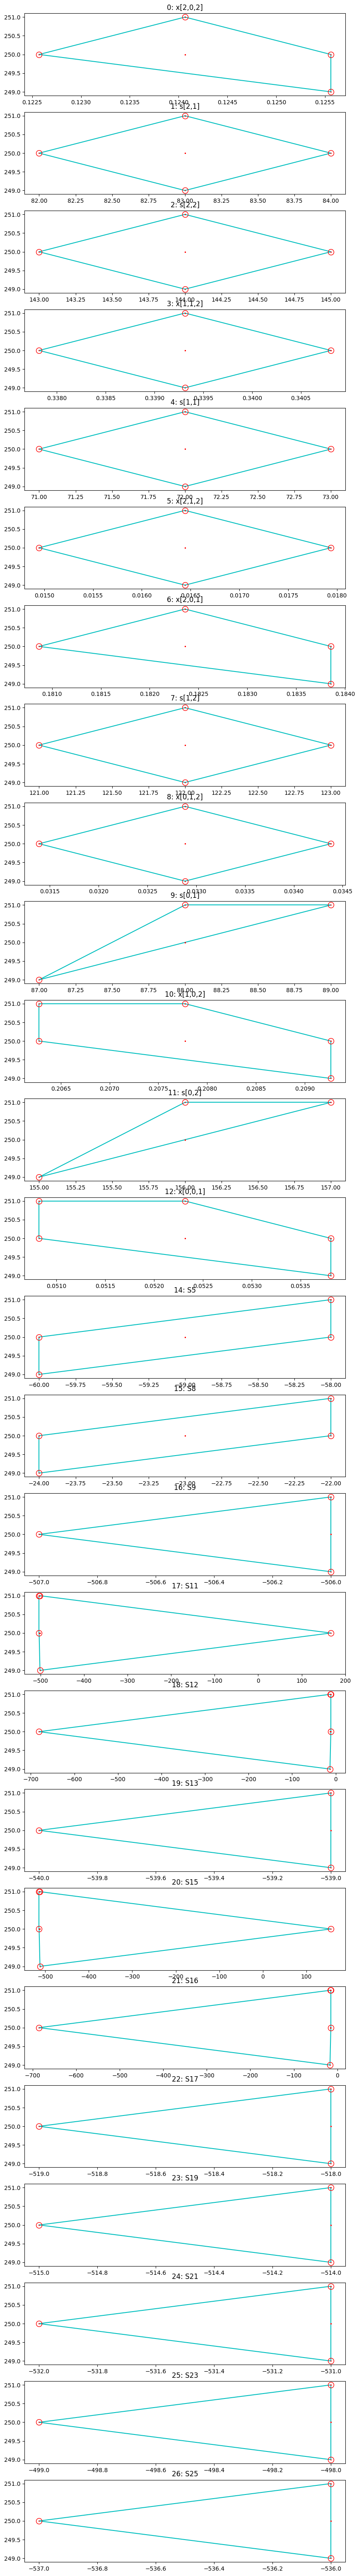

In [14]:
import scipy.spatial as ss
import matplotlib.pyplot as plt

# for each row != c_max
#   for all columns
#     list.add(copy vector onto relaxation point)
#   hull = convex_hull(list)
#   render hull
cons = model.getConstrs()
def getVarValue(idx):
    if idx < len(variables):
        return variables[idx].X
    idx -= len(variables)
    return cons[idx].Slack

cmax_idx = row_names.index('c_max')
cx = np.array([getVarValue(b) for b in basis])

fig, ax = plt.subplots(tableau.shape[0] - 1, 1, figsize=(10, 80))
ri2 = 0
for ri, row in enumerate(tableau):
    if ri == cmax_idx:
        continue
    points = np.zeros((len(row), 2))
    for ci, col in enumerate(row):
        cmax_val = tableau[cmax_idx, ci]
        # limit the length of the vector here?
        points[ci, :] = np.array([col, cmax_val]) + cx[[ri, cmax_idx]]
    
    hull = ss.ConvexHull(points)
    ax[ri2].set_title(f"{ri}: {row_names[ri]}")
    for simplex in hull.simplices:
        ax[ri2].plot(points[simplex, 0], points[simplex, 1], 'c')
    ax[ri2].plot(points[hull.vertices, 0], points[hull.vertices, 1], 'o', mec='r', color='none', lw=1, markersize=10)
    ax[ri2].plot(points[:, 0], points[:, 1], 'o', mec='r', color='white', lw=1, markersize=1)
    ri2 += 1